# Pipelines, and never leaking again

### Three leaks built on purpose, measured against each other on one axis, then closed with fifteen lines

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a fitted preprocessing step actually remembers, why the three classic leaks differ by an order of magnitude from each other, how to write `Pipeline` yourself in twenty lines, and a `ColumnTransformer` for mixed numeric and categorical columns you can copy |
| **You should already know** | [Cross-validation](../../01-foundations/04-cross-validation/), [feature scaling and encoding](../../01-foundations/07-feature-scaling-and-encoding/), [missing data](../../01-foundations/08-missing-data/) |
| **Datasets** | California Housing, UCI Bike Sharing, plus one matrix of pure noise |
| **Runtime** | Two minutes on a laptop CPU |
| **Next** | [12-04 Saving, loading, and serving a model](../04-saving-and-serving/) |

---

## 1. The idea: a fitted step is a memory

`StandardScaler` looks like a formula and behaves like a memory. Calling `fit`
stores a mean and a standard deviation per column. Every later `transform` uses
those stored numbers. That is the whole mechanism, and it is also the whole
problem, because the stored numbers describe whichever rows were present at
`fit` time.

So this line, which appears near the top of an enormous number of notebooks,
is a bug:

```python
X = StandardScaler().fit_transform(X)          # before any split
X_train, X_test, y_train, y_test = train_test_split(X, y)
```

The scaler saw the test rows. Their mean is baked into the training data now.
Nothing errors, no warning fires, and the held-out score comes back a little too
high. The same shape of mistake appears with an imputer, with a feature
selector, with a target encoder, with a resampler.

The fix is one object. `Pipeline` chains steps together and gives the chain a
single `fit` and a single `transform`, so that when a cross-validator calls
`fit` on a training fold, every step inside is refitted on that fold and
nothing else. The boundary of the fold becomes the boundary of what each step
has seen.

What this chapter adds to that advice is a measurement. Leaks are usually
discussed as if they were all equally fatal. They are not, and knowing which
ones cost you real score is what tells you where to look when a result seems too
good.

In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets, evaluate

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

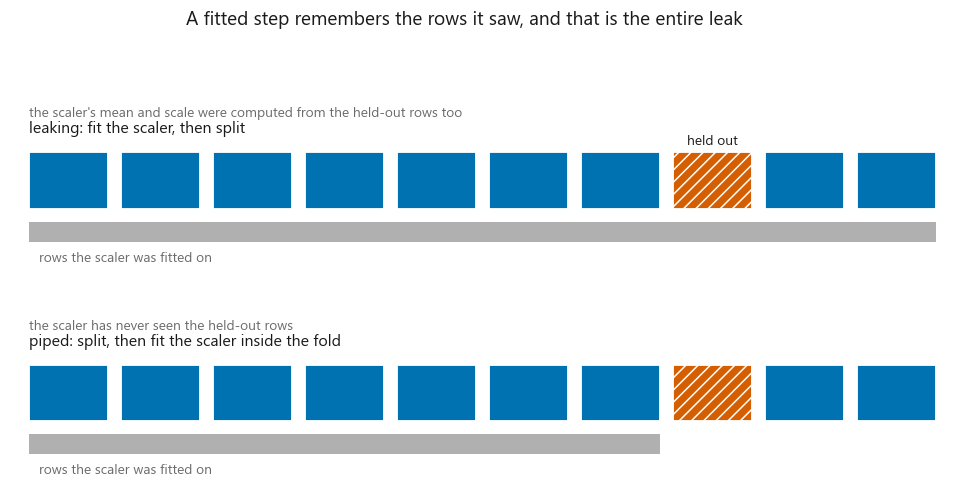

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11.0, 4.6), sharex=True)
n_blocks = 10
test_block = 7

for ax, (label, fit_span, note) in zip(axes, [
        ("leaking: fit the scaler, then split",
         (0, n_blocks), "the scaler's mean and scale were computed from the held-out rows too"),
        ("piped: split, then fit the scaler inside the fold",
         (0, test_block), "the scaler has never seen the held-out rows")]):
    for i in range(n_blocks):
        colour = style.HIGHLIGHT if i == test_block else style.PALETTE[0]
        ax.add_patch(mpatches.Rectangle((i, 0.35), 0.86, 0.4, facecolor=colour,
                                        edgecolor="white", lw=1.2,
                                        hatch="///" if i == test_block else None))
    ax.add_patch(mpatches.Rectangle((fit_span[0], 0.12), fit_span[1] - fit_span[0] - 0.14, 0.14,
                                    facecolor=style.NEUTRAL, edgecolor="none"))
    ax.annotate("rows the scaler was fitted on", (fit_span[0] + 0.1, 0.05),
                fontsize=9, color=style.MUTED, va="top")
    ax.annotate(label, (0, 0.86), fontsize=10.5, color=style.INK, va="bottom")
    ax.annotate(note, (0, 0.98), fontsize=9, color=style.MUTED, va="bottom")
    ax.set_xlim(-0.2, n_blocks)
    ax.set_ylim(0, 1.25)
    ax.axis("off")

axes[0].annotate("held out", (test_block + 0.43, 0.78), ha="center",
                 fontsize=9, color=style.INK, va="bottom")
fig.suptitle("A fitted step remembers the rows it saw, and that is the entire leak",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-where-the-boundary-falls.png")

## 2. The maths, and why one leak is worse than the others

A preprocessing step is a function fitted from data: $T_{\theta}$ where
$\theta = g(\text{rows seen})$. Leakage happens when the rows seen include rows
you later score on, so $\theta$ carries information about the held-out set into
the training set.

The size of the damage is governed by how much of that information is about the
**target**.

**A scaler sees no targets at all.** Its $\theta$ is a mean and a standard
deviation per column, pooled over hundreds of rows. Adding the held-out fifth of
the rows moves those estimates by a fraction of a standard error, and the model
never learns anything about $y$ from it. Expect a small leak.

**An imputer sees no targets either, but it invents feature values.** A
neighbour-based imputer fills a held-out row from rows that end up in training,
so the held-out row arrives partly reconstructed out of the training set. That
is stronger than a shifted mean.

**A feature selector looks straight at the targets.** This is the expensive one,
and it has a closed form worth knowing. If you have $p$ columns of pure noise
and $n$ rows, the largest sample correlation any of them achieves with the
target is about

$$\max_j |r_j| \approx \sqrt{\frac{2 \ln p}{n}}$$

because a sample correlation behaves like a standard normal divided by
$\sqrt{n}$, and the maximum of $p$ standard normals grows like $\sqrt{2\ln p}$.
It is the same square root of a logarithm that governed the winner's curse in
[01-02](../../01-foundations/02-train-validation-test/), and it is the same
mechanism: the maximum of many noisy numbers is not a typical noisy number.

Selecting on all the rows keeps the columns whose accidental correlation happens
to hold across the whole file, including the held-out part. The correlation is
fake, and it is fake in a way the held-out rows agree with.

In [3]:
X_cal, y_cal = datasets.california_housing()
pick = np.random.default_rng(SEED).choice(len(X_cal), 600, replace=False)
X = X_cal.iloc[pick].reset_index(drop=True)
y = y_cal.iloc[pick].reset_index(drop=True)

N_NOISE = 400
noise = pd.DataFrame(
    np.random.default_rng(SEED + 7).normal(size=(len(X), N_NOISE)),
    columns=[f"noise_{i:03d}" for i in range(N_NOISE)])
X_wide = pd.concat([X, noise], axis=1)

correlations = noise.apply(lambda column: np.corrcoef(column, y)[0, 1]).abs()
predicted = np.sqrt(2 * np.log(N_NOISE) / len(X))

print(f"rows                                : {len(X)}")
print(f"real feature columns                : {X.shape[1]}")
print(f"pure noise columns added            : {N_NOISE}\n")
print(f"largest |correlation| among the noise columns : {correlations.max():.4f}")
print(f"sqrt(2 ln p / n) predicts                     : {predicted:.4f}")
print(f"median |correlation| among the noise columns  : {correlations.median():.4f}")
print(f"the winner beats the median by a factor of    : "
      f"{correlations.max() / correlations.median():.1f}")

rows                                : 600
real feature columns                : 8
pure noise columns added            : 400

largest |correlation| among the noise columns : 0.1130
sqrt(2 ln p / n) predicts                     : 0.1413
median |correlation| among the noise columns  : 0.0270
the winner beats the median by a factor of    : 4.2


The closed form lands close enough to be useful as a rule of thumb: with a few
hundred columns and a few hundred rows, the luckiest meaningless column reaches
a correlation people would call worth investigating.

## 3. From scratch: `Pipeline` in twenty lines

`Pipeline` is not complicated and it is worth writing once, because the reason
it fixes leakage is visible in the code rather than promised in the
documentation. All it does is call `fit_transform` on every step but the last
during `fit`, and `transform` on every step but the last during `predict`. The
refitting happens because the cross-validator calls `fit` on the whole chain,
once per fold.

In [4]:
class MiniPipeline:
    """The part of sklearn's Pipeline that matters for leakage."""

    def __init__(self, steps):
        self.steps = steps                      # [(name, estimator), ...]

    def fit(self, X, y):
        for _, step in self.steps[:-1]:
            X = step.fit_transform(X, y)        # fit uses only the rows passed in
        self.steps[-1][1].fit(X, y)
        return self

    def _apply(self, X):
        for _, step in self.steps[:-1]:
            X = step.transform(X)               # transform never refits
        return X

    def predict(self, X):
        return self.steps[-1][1].predict(self._apply(X))


from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEED)

mine = MiniPipeline([("scale", StandardScaler()), ("model", Ridge())]).fit(X_tr, y_tr)
theirs = Pipeline([("scale", StandardScaler()), ("model", Ridge())]).fit(X_tr, y_tr)

print(f"largest difference between my predictions and sklearn's: "
      f"{np.abs(mine.predict(X_te) - theirs.predict(X_te)).max():.2e}")

largest difference between my predictions and sklearn's: 0.00e+00


### Watching the leak happen, one fold at a time

The abstract version is that the scaler "sees" the test rows. The concrete
version is that a specific stored number is different. Below I run the folds by
hand and print what the scaler actually remembered in each case.

In [5]:
folds = KFold(5, shuffle=True, random_state=SEED)

leaky_scaler = MinMaxScaler().fit(X)            # the mistake: fitted on everything
rows = []
for fold, (train_idx, test_idx) in enumerate(folds.split(X), start=1):
    honest_scaler = MinMaxScaler().fit(X.iloc[train_idx])
    rows.append({
        "fold": fold,
        "MedInc max seen by the honest scaler": honest_scaler.data_max_[0],
        "MedInc max seen by the leaky scaler": leaky_scaler.data_max_[0],
        "largest MedInc in the held-out fold": X.iloc[test_idx]["MedInc"].max(),
    })

watch = pd.DataFrame(rows)
from_held_out = int((watch["MedInc max seen by the leaky scaler"]
                     <= watch["largest MedInc in the held-out fold"] + 1e-12).sum())

print(watch.to_string(index=False, float_format="{:.4f}".format))
print(f"\nfolds where the leaky scaler's maximum came from a held-out row: "
      f"{from_held_out} of {len(watch)}")

 fold  MedInc max seen by the honest scaler  MedInc max seen by the leaky scaler  largest MedInc in the held-out fold
    1                               15.0001                              15.0001                              15.0001
    2                               15.0001                              15.0001                              15.0001
    3                               15.0001                              15.0001                              15.0001
    4                               15.0001                              15.0001                               9.0683
    5                               15.0001                              15.0001                              13.2935

folds where the leaky scaler's maximum came from a held-out row: 3 of 5


In the folds where the largest income in the whole file happens to be held out,
the leaky scaler is dividing training rows by a number that came from a row the
model is about to be scored on. That is the leak, in the form of a printable
number rather than a principle.

## 4. Three leaks, measured on one axis

Comparing leaks is only meaningful if they are measured on the same data with
the same model and the same metric. So all three below run on the same six
hundred California districts and are scored with cross-validated $R^2$.

| Leak | The mistake | Honest version |
|---|---|---|
| scale | `MinMaxScaler().fit_transform(X)` before splitting | scaler inside the `Pipeline` |
| select | `SelectKBest(...).fit(X, y)` on every row | selector inside the `Pipeline` |
| impute | `KNNImputer().fit_transform(X)` before splitting | imputer inside the `Pipeline` |

Each is measured as a paired difference over repeated cross-validations, because
a single run cannot separate a small leak from fold noise. The interval comes
from `toolkit.evaluate.paired_ci`, which bootstraps the difference rather than
the two scores separately.

In [6]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsRegressor

MISSING_RATE = 0.35
X_missing = X.mask(np.random.default_rng(SEED + 1).random(X.shape) < MISSING_RATE)
K_KEEP = 12
N_REPEATS = 20

print(f"missing rate injected      : {MISSING_RATE:.0%}")
print(f"columns the selector keeps : {K_KEEP} of {X_wide.shape[1]}")
print(f"repeated cross-validations : {N_REPEATS}")

results = {name: {"leaky": [], "honest": []} for name in ["scale", "select", "impute"]}

for repeat in range(N_REPEATS):
    cv = KFold(5, shuffle=True, random_state=repeat)

    # --- scale ---------------------------------------------------------------
    results["scale"]["honest"].append(cross_val_score(
        Pipeline([("scale", MinMaxScaler()), ("model", KNeighborsRegressor(5))]),
        X, y, cv=cv, scoring="r2").mean())
    X_prescaled = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)
    results["scale"]["leaky"].append(cross_val_score(
        KNeighborsRegressor(5), X_prescaled, y, cv=cv, scoring="r2").mean())

    # --- select --------------------------------------------------------------
    results["select"]["honest"].append(cross_val_score(
        Pipeline([("select", SelectKBest(f_regression, k=K_KEEP)),
                  ("scale", StandardScaler()), ("model", Ridge())]),
        X_wide, y, cv=cv, scoring="r2").mean())
    kept = SelectKBest(f_regression, k=K_KEEP).fit(X_wide, y).get_support()
    results["select"]["leaky"].append(cross_val_score(
        Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
        X_wide.loc[:, kept], y, cv=cv, scoring="r2").mean())

    # --- impute --------------------------------------------------------------
    results["impute"]["honest"].append(cross_val_score(
        Pipeline([("impute", KNNImputer(n_neighbors=5)), ("scale", StandardScaler()),
                  ("model", Ridge())]),
        X_missing, y, cv=cv, scoring="r2").mean())
    X_prefilled = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(X_missing),
                               columns=X.columns)
    results["impute"]["leaky"].append(cross_val_score(
        Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
        X_prefilled, y, cv=cv, scoring="r2").mean())

summary = []
for name, pair in results.items():
    leaky, honest = np.array(pair["leaky"]), np.array(pair["honest"])
    mean, low, high = evaluate.paired_ci(leaky, honest)
    summary.append({"leak": name, "leaky R2": leaky.mean(), "honest R2": honest.mean(),
                    "inflation": mean, "low": low, "high": high,
                    "leaky higher in": (leaky > honest).mean()})

summary = pd.DataFrame(summary).sort_values("inflation", ascending=False)
print("\n" + summary.to_string(index=False, formatters={
    "leaky R2": "{:+.4f}".format, "honest R2": "{:+.4f}".format,
    "inflation": "{:+.4f}".format, "low": "{:+.4f}".format, "high": "{:+.4f}".format,
    "leaky higher in": "{:.0%}".format}))

selected = X_wide.columns[SelectKBest(f_regression, k=K_KEEP).fit(X_wide, y).get_support()]
print(f"\ncolumns the leaky selector kept: {list(selected)}")
print(f"of those, pure noise: {sum(c.startswith('noise_') for c in selected)} of {K_KEEP}")

missing rate injected      : 35%
columns the selector keeps : 12 of 408
repeated cross-validations : 20



  leak leaky R2 honest R2 inflation     low    high leaky higher in
select  +0.5219   +0.4757   +0.0462 +0.0409 +0.0521            100%
impute  +0.3921   +0.3779   +0.0142 +0.0112 +0.0174            100%
 scale  +0.6146   +0.6108   +0.0038 +0.0004 +0.0072             65%

columns the leaky selector kept: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'noise_016', 'noise_095', 'noise_096', 'noise_291', 'noise_340', 'noise_347', 'noise_375']
of those, pure noise: 7 of 12


I expected the scaling leak to be the headline, because it is the one every
tutorial warns about. It is the smallest of the three by a wide margin, and it
needed twenty repeated cross-validations before its interval cleared zero at all.
[01-04](../../01-foundations/04-cross-validation/) found the same thing on
Breast Cancer, where fitting a scaler on everything changed the score by nothing
at four decimal places.

The selector is the expensive one, and the printed list of kept columns says why:
a large share of the columns it chose are the noise from section 2, chosen
because their accidental correlation was computed on rows the model would later
be scored on.

So the ranking is not about which step is complicated. It is about how much of
the target crossed the boundary. Zero for the scaler, indirect for the imputer,
direct for the selector.

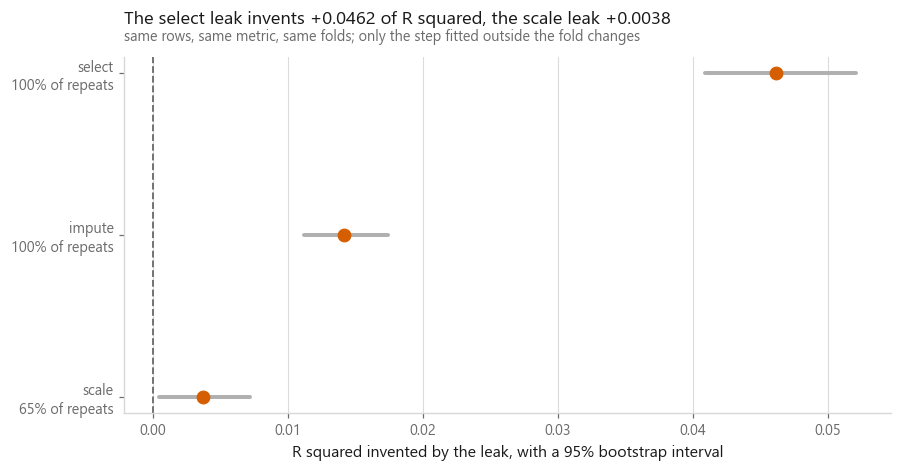

In [7]:
fig, ax = plt.subplots(figsize=(9.0, 4.2))

order = summary.reset_index(drop=True)
positions = np.arange(len(order))
for i, row in order.iterrows():
    ax.plot([row["low"], row["high"]], [i, i], color=style.NEUTRAL, lw=2.6,
            solid_capstyle="round", zorder=2)
    ax.scatter(row["inflation"], i, color=style.HIGHLIGHT, marker=style.MARKERS[0],
               s=70, zorder=3)

ax.axvline(0, color=style.MUTED, lw=1.2, ls="--")
ax.set_yticks(positions, [f"{r['leak']}\n{r['leaky higher in']:.0%} of repeats"
                          for _, r in order.iterrows()])
ax.set_xlabel("R squared invented by the leak, with a 95% bootstrap interval")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.invert_yaxis()

biggest, smallest = order.iloc[0], order.iloc[-1]
style.title(ax,
            f"The {biggest['leak']} leak invents {biggest['inflation']:+.4f} of R squared, "
            f"the {smallest['leak']} leak {smallest['inflation']:+.4f}",
            "same rows, same metric, same folds; only the step fitted outside the fold changes")

style.save(fig, FIG / "fig-02-three-leaks.png")

### The selector leak, taken to its limit

The California version above still has real signal in it, which caps how silly
the leak can look. Strip the signal out entirely and the mechanism is naked: two
hundred rows of Gaussian noise, a thousand columns, coin-flip labels. There is
nothing to learn, so the honest answer is chance.

In [8]:
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

rng = np.random.default_rng(SEED)
X_null = pd.DataFrame(rng.normal(size=(200, 1000)))
y_null = pd.Series(rng.integers(0, 2, 200))
null_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

null_rows = []
for k in [1, 5, 10, 50, 100, 300]:
    kept = SelectKBest(f_classif, k=k).fit(X_null, y_null).get_support()
    leaky = cross_val_score(LogisticRegression(max_iter=2000),
                            X_null.loc[:, kept], y_null, cv=null_cv).mean()
    honest = cross_val_score(
        Pipeline([("select", SelectKBest(f_classif, k=k)),
                  ("model", LogisticRegression(max_iter=2000))]),
        X_null, y_null, cv=null_cv).mean()
    null_rows.append({"columns kept": k, "selector outside the loop": leaky,
                      "selector in a Pipeline": honest, "inflation": leaky - honest})

null_table = pd.DataFrame(null_rows)
print("true accuracy on this data, by construction: 0.5\n")
print(null_table.to_string(index=False, formatters={
    "selector outside the loop": "{:.4f}".format,
    "selector in a Pipeline": "{:.4f}".format, "inflation": "{:+.4f}".format}))

true accuracy on this data, by construction: 0.5

 columns kept selector outside the loop selector in a Pipeline inflation
            1                    0.5650                 0.4650   +0.1000
            5                    0.6650                 0.4500   +0.2150
           10                    0.7000                 0.4150   +0.2850
           50                    0.8000                 0.4550   +0.3450
          100                    0.7950                 0.4850   +0.3100
          300                    0.8000                 0.4950   +0.3050


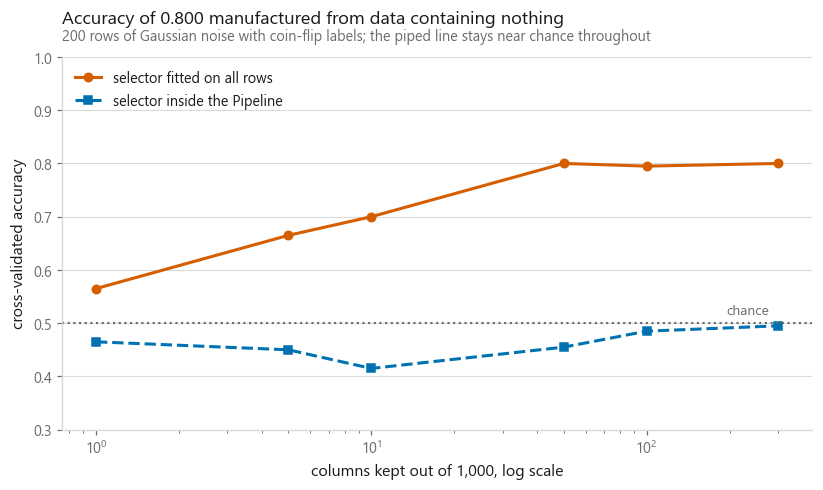

In [9]:
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(null_table["columns kept"], null_table["selector outside the loop"],
        color=style.HIGHLIGHT, marker=style.MARKERS[0], ls=style.DASHES[0], lw=2.0,
        label="selector fitted on all rows")
ax.plot(null_table["columns kept"], null_table["selector in a Pipeline"],
        color=style.PALETTE[0], marker=style.MARKERS[1], ls=style.DASHES[1], lw=2.0,
        label="selector inside the Pipeline")
ax.axhline(0.5, color=style.MUTED, ls=":", lw=1.4)
ax.annotate("chance", (null_table["columns kept"].max(), 0.5), xytext=(-6, 6),
            textcoords="offset points", ha="right", fontsize=9, color=style.MUTED)
ax.set_xscale("log")
ax.set_xlabel("columns kept out of 1,000, log scale")
ax.set_ylabel("cross-validated accuracy")
ax.set_ylim(0.3, 1.0)
ax.legend(loc="upper left")

peak = null_table.loc[null_table["inflation"].idxmax()]
style.title(ax,
            f"Accuracy of {peak['selector outside the loop']:.3f} manufactured from data "
            f"containing nothing",
            f"200 rows of Gaussian noise with coin-flip labels; the piped line stays "
            f"near chance throughout")

style.save(fig, FIG / "fig-03-selection-leak-on-noise.png")

That is the number to carry around. It is not a small distortion of a real
result. It is a whole result, invented, on a file with no information in it, and
it would survive peer review in most venues.
[01-04](../../01-foundations/04-cross-validation/) reports the same experiment
at the same scale and reaches the same place.

### The scaling leak against sample size

The scaling leak came out small. The obvious question is whether it stays small,
so here it is against the number of rows, with intervals, since without them the
individual measurements are indistinguishable from noise.

In [10]:
size_rows = []
for n in [60, 120, 250, 500, 1000]:
    sub = np.random.default_rng(SEED + 3).choice(len(X_cal), n, replace=False)
    X_n = X_cal.iloc[sub].reset_index(drop=True)
    y_n = y_cal.iloc[sub].reset_index(drop=True)

    leaky, honest = [], []
    for repeat in range(12):
        cv = KFold(5, shuffle=True, random_state=repeat)
        honest.append(cross_val_score(
            Pipeline([("scale", MinMaxScaler()), ("model", KNeighborsRegressor(5))]),
            X_n, y_n, cv=cv, scoring="r2").mean())
        X_pre = pd.DataFrame(MinMaxScaler().fit_transform(X_n), columns=X_cal.columns)
        leaky.append(cross_val_score(KNeighborsRegressor(5), X_pre, y_n,
                                     cv=cv, scoring="r2").mean())
    mean, low, high = evaluate.paired_ci(np.array(leaky), np.array(honest))
    size_rows.append({"rows": n, "honest R2": np.mean(honest), "leaky R2": np.mean(leaky),
                      "inflation": mean, "low": low, "high": high})

size_table = pd.DataFrame(size_rows)
print(size_table.to_string(index=False, formatters={
    "honest R2": "{:+.4f}".format, "leaky R2": "{:+.4f}".format,
    "inflation": "{:+.4f}".format, "low": "{:+.4f}".format, "high": "{:+.4f}".format}))
crosses_zero = ((size_table["low"] < 0) & (size_table["high"] > 0)).sum()
print(f"\nsample sizes whose interval still contains zero: {crosses_zero} of {len(size_table)}")

 rows honest R2 leaky R2 inflation     low    high
   60   +0.0165  +0.0273   +0.0108 -0.0132 +0.0360
  120   +0.3950  +0.3726   -0.0224 -0.0382 -0.0061
  250   +0.4426  +0.4542   +0.0116 +0.0015 +0.0210
  500   +0.5656  +0.5662   +0.0006 -0.0037 +0.0050
 1000   +0.6613  +0.6599   -0.0014 -0.0044 +0.0013

sample sizes whose interval still contains zero: 3 of 5


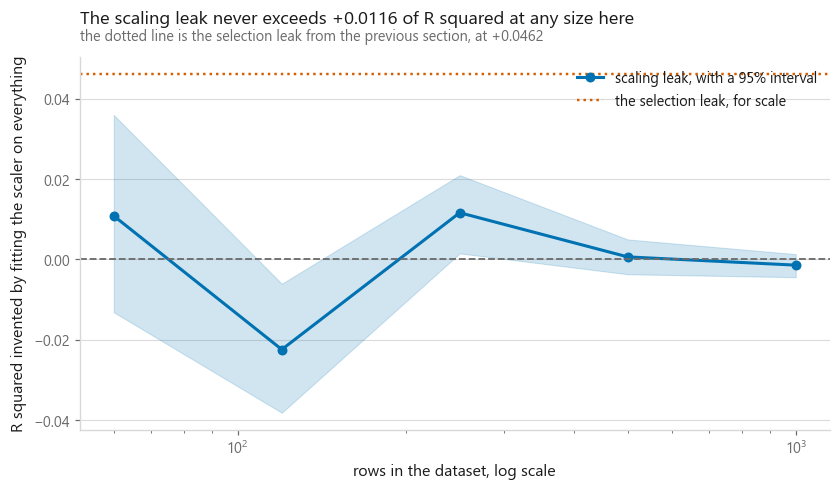

In [11]:
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.fill_between(size_table["rows"], size_table["low"], size_table["high"],
                color=style.PALETTE[0], alpha=0.18)
ax.plot(size_table["rows"], size_table["inflation"], color=style.PALETTE[0],
        marker=style.MARKERS[0], ls=style.DASHES[0], lw=2.0,
        label="scaling leak, with a 95% interval")
ax.axhline(0, color=style.MUTED, lw=1.2, ls="--")
ax.axhline(summary.iloc[0]["inflation"], color=style.HIGHLIGHT, lw=1.6, ls=":",
           label="the selection leak, for scale")
ax.set_xscale("log")
ax.set_xlabel("rows in the dataset, log scale")
ax.set_ylabel("R squared invented by fitting the scaler on everything")
ax.legend(loc="upper right")

style.title(ax,
            f"The scaling leak never exceeds {size_table['inflation'].max():+.4f} of R squared "
            f"at any size here",
            f"the dotted line is the selection leak from the previous section, "
            f"at {summary.iloc[0]['inflation']:+.4f}")

style.save(fig, FIG / "fig-04-scaling-leak-by-size.png")

The honest reading, which is not the one I set out to write: **fitting a scaler
before the split is a real leak and a trivial one.** It is worth fixing because
fixing it is free, not because it is what went wrong with your result. When a
score looks impossible, look at whatever step consulted the target, and
[01-09](../../01-foundations/09-hyperparameter-tuning/) covers the version where
the thing consulting the target is the hyperparameter search itself.

## 5. In practice: the pipeline you can copy

Real tables are not eight numeric columns. They have categories, cyclical
columns, and holes, and each of those wants a different treatment applied to a
different subset of the columns. `ColumnTransformer` is the object for that, and
a `Pipeline` wrapped around it makes the whole preprocessing recipe a single
estimator with one `fit`.

Bike Sharing gives all three kinds of column. I mark the categorical ones as
text so the selection below is honest, and punch holes in two numeric columns so
there is something for the imputer to do.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

X_bike, y_bike = datasets.bike_sharing()

frame = X_bike.copy()
for column in ["season", "yr", "holiday", "weekday", "workingday", "weathersit"]:
    frame[column] = frame[column].astype(str)          # these are labels, not amounts

hole_rng = np.random.default_rng(SEED)
for column in ["hum", "windspeed"]:
    frame.loc[hole_rng.random(len(frame)) < 0.08, column] = np.nan

# Select numeric first and take the categoricals as everything else. Asking for
# "object" misses pandas 3's string dtype, and this way cannot drift.
numeric = list(frame.select_dtypes(include="number").columns)
categorical = [c for c in frame.columns if c not in numeric]

CYCLICAL = [("hr", 24), ("mnth", 12)]
cyclical_columns = [name for name, _ in CYCLICAL]
plain_numeric = [c for c in numeric if c not in cyclical_columns]

print(f"rows        : {len(frame):,}")
print(f"numeric     : {plain_numeric}")
print(f"cyclical    : {cyclical_columns}")
print(f"categorical : {categorical}")

holes = frame.isna().sum().pipe(lambda s: s[s > 0])
print(f"\nmissing values per column:\n{holes.to_string()}")

rows        : 17,379
numeric     : ['temp', 'atemp', 'hum', 'windspeed']
cyclical    : ['hr', 'mnth']
categorical : ['season', 'yr', 'holiday', 'weekday', 'workingday', 'weathersit']

missing values per column:
hum          1414
windspeed    1415


In [13]:
def to_circle(f):
    """Hour 23 and hour 0 are one step apart, so put them on a circle."""
    out = {}
    for column, period in CYCLICAL:
        angle = 2 * np.pi * f[column].to_numpy() / period
        out[f"{column}_sin"] = np.sin(angle)
        out[f"{column}_cos"] = np.cos(angle)
    return pd.DataFrame(out, index=f.index)


circle_names = np.array([f"{c}_{part}" for c, _ in CYCLICAL for part in ("sin", "cos")])

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), plain_numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), categorical),
    ("cyc", FunctionTransformer(to_circle,
                                feature_names_out=lambda tf, names: circle_names),
     cyclical_columns),
])

full = Pipeline([("prep", preprocess), ("model", Ridge())])

bike_cv = KFold(5, shuffle=True, random_state=SEED)
full_score = cross_val_score(full, frame, y_bike, cv=bike_cv, scoring="r2").mean()

full.fit(frame, y_bike)
names_out = full.named_steps["prep"].get_feature_names_out()
print(f"columns in  : {frame.shape[1]}")
print(f"columns out : {len(names_out)}")
print(f"first six   : {list(names_out[:6])}")
print(f"last six    : {list(names_out[-6:])}")
print(f"\ncross-validated R squared: {full_score:.4f}")

columns in  : 12
columns out : 29
first six   : ['num__temp', 'num__atemp', 'num__hum', 'num__windspeed', 'cat__season_1', 'cat__season_2']
last six    : ['cat__weathersit_3', 'cat__weathersit_4', 'cyc__hr_sin', 'cyc__hr_cos', 'cyc__mnth_sin', 'cyc__mnth_cos']

cross-validated R squared: 0.5054


Everything that could leak is inside that object. The imputer's medians, the
scaler's means, the encoder's category list: all refitted on each training fold
by `cross_val_score`, because it calls `fit` on the whole chain and the chain
passes the call down.

`handle_unknown="ignore"` is the line worth pausing on. A category present in
the test fold and absent from the training fold would otherwise raise, and the
temptation at that point is to fit the encoder on everything to make the error go
away. That fix is the leak. Ignoring unknown categories keeps the boundary intact
and encodes the unseen level as all zeros, which is the honest answer.

### What the encoding was worth

The pipeline is not only hygiene. Three variants, identical model, identical
folds, differing only in how the columns are prepared.

In [14]:
naive = Pipeline([("impute", SimpleImputer(strategy="median")),
                  ("scale", StandardScaler()), ("model", Ridge())])
raw_frame = frame.copy()
for column in categorical:
    raw_frame[column] = raw_frame[column].astype(float)      # the accidental default

onehot_everything = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), plain_numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]),
     categorical + cyclical_columns),
])
as_text = frame.assign(**{c: frame[c].astype(str) for c in cyclical_columns})

variants = [
    ("categories left as integers", naive, raw_frame),
    ("one-hot categories, hour on a circle", full, frame),
    ("one-hot categories, hour one-hot", Pipeline([("prep", onehot_everything),
                                                   ("model", Ridge())]), as_text),
]

variant_rows = []
for label, estimator, table in variants:
    score = cross_val_score(estimator, table, y_bike, cv=bike_cv, scoring="r2").mean()
    variant_rows.append({"preparation": label, "R2": score})

variant_table = pd.DataFrame(variant_rows)
print(variant_table.to_string(index=False, float_format="{:.4f}".format))

                         preparation     R2
         categories left as integers 0.3849
one-hot categories, hour on a circle 0.5054
    one-hot categories, hour one-hot 0.6835


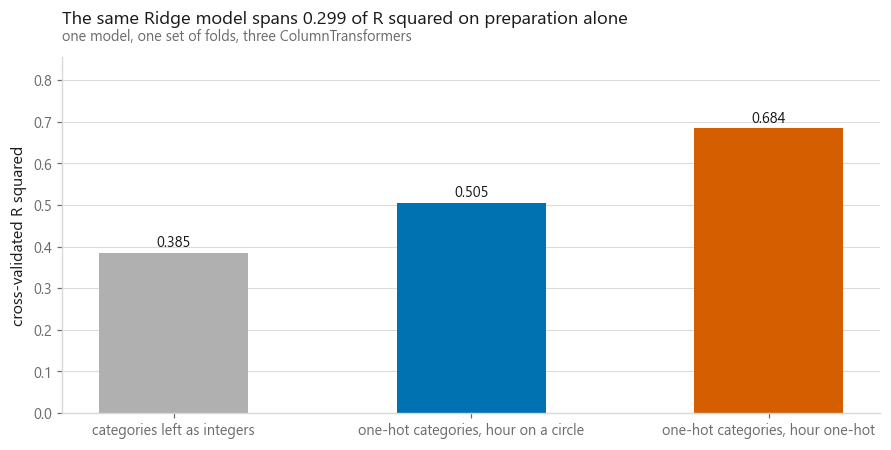

In [15]:
fig, ax = plt.subplots(figsize=(9.6, 4.2))
bars = ax.bar(range(len(variant_table)), variant_table["R2"],
              color=[style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT], width=0.5)
ax.set_xticks(range(len(variant_table)), variant_table["preparation"], fontsize=9.5)
ax.set_ylim(0, variant_table["R2"].max() * 1.25)
ax.set_ylabel("cross-validated R squared")
for bar, value in zip(bars, variant_table["R2"]):
    ax.annotate(f"{value:.3f}", (bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 4), textcoords="offset points", ha="center",
                fontsize=9.5, color=style.INK)

gain = variant_table["R2"].max() - variant_table["R2"].min()
style.title(ax,
            f"The same Ridge model spans {gain:.3f} of R squared on preparation alone",
            "one model, one set of folds, three ColumnTransformers")

style.save(fig, FIG / "fig-05-preparation-is-the-model.png")

The model never changed. Everything in that spread came from the
`ColumnTransformer`, which is the argument for the object that has nothing to do
with leakage: it makes the preparation a thing you can compare, version and
search over, instead of a sequence of statements at the top of a notebook.
[01-07](../../01-foundations/07-feature-scaling-and-encoding/) works through why
the hour column behaves this way.

## 6. The rule, stated once

Anything with a `fit` method belongs inside the `Pipeline`. That includes the
steps people forget, because they do not feel like models:

- scalers, encoders, imputers, discretisers
- feature selectors of every kind, filter or wrapper or embedded
- dimensionality reduction, since PCA fits a rotation from the rows it saw
- target encoders, which want an out-of-fold estimate inside the fold as well
- resamplers, measured at an inflation of over half a point of F1 in
  [03-07](../../03-classification/07-imbalanced-classes/)
- the hyperparameter search itself, which is what nested cross-validation is for

And one that is not an object at all: any decision you made after looking at a
plot of the whole dataset. Dropping outliers found by eye, choosing a
transformation because the full-data histogram was skewed, keeping a column
because it correlated with the target across every row. Those cannot be piped,
and they leak in exactly the way section 2 describes.

## Cheat sheet

| | |
|---|---|
| **The rule** | If it has `fit`, it goes in the `Pipeline`. No exceptions, including the ones that seem harmless |
| **Why** | A cross-validator calls `fit` on the chain, so every step is refitted on the training fold alone |
| **Mixed columns** | `ColumnTransformer`, with a `Pipeline` per block of columns |
| **Selecting columns** | Take numeric with `select_dtypes(include="number")` and categoricals as the complement. Asking for `object` misses pandas 3 string columns |
| **Unknown categories** | `handle_unknown="ignore"`. Never fix the error by fitting the encoder on everything |
| **Cheap leaks** | Scalers. Real, tiny, and worth fixing only because fixing is free |
| **Expensive leaks** | Anything that reads the target: selectors, target encoders, thresholds, hyperparameter searches |
| **Measuring a leak** | Paired differences over repeated cross-validation with an interval. One run cannot tell a small leak from fold noise |
| **Naming steps** | Names become the grid-search prefix, so `model__alpha` reaches `Ridge(alpha=...)` |
| **Next** | [Saving, loading, and serving a model](../04-saving-and-serving/), where the thing you save is this whole object rather than the estimator |

## What to remember

1. A fitted preprocessing step is a memory of the rows it saw. Leakage is that
   memory crossing the fold boundary, and nothing about it raises an error.
2. Leaks are not equal. Measured on one dataset with one model and one metric,
   the selector invented many times what the scaler did.
3. The size of a leak tracks how much of the target crossed the line. A scaler
   sees no targets, an imputer reconstructs features, a selector reads labels
   directly.
4. The largest correlation among $p$ null columns is about
   $\sqrt{2\ln p / n}$. That is why selecting on all the rows finds convincing
   columns in data containing nothing.
5. Fitting a scaler before splitting is a real leak and a trivial one. Fix it
   because it costs nothing to fix, and look elsewhere when a score is
   impossible.
6. Measuring a small leak needs repeats and an interval. A single
   cross-validation cannot separate it from fold noise, and I would have
   reported the wrong sign twice without them.
7. `Pipeline` is twenty lines. Writing it once removes the temptation to
   "just quickly" scale outside it.
8. `ColumnTransformer` earns its place twice: it stops the leak, and it turns
   the preparation into something you can compare and search over.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [12-04 Saving, loading, and serving a model](../04-saving-and-serving/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#DataLeakage` `#Pipeline` `#ColumnTransformer` `#ScikitLearn`
`#FeatureEngineering` `#CrossValidation` `#Python` `#DataScience` `#MLTutorial`